In [197]:
import numpy as np
import pandas as pd
import keras
import matplotlib.pyplot as plt
from keras import layers
import openpyxl as xl
from openpyxl.styles import Font
import os

In [198]:
#Coletando dados

df = pd.read_excel('/Users/PC/Documents/Proj_MPA/Recontrucao/RJ/Clupeiformes/R.xlsx')



#Dados iniciais
df_especies = df[['Ano',"Sar_boca_torta_art", "Sar_boca_torta_ind", "Sar_cascuda_art", "Sar_cascuda_ind", "Sar_laje_art", "Sar_laje_ind", "Sar_verdadeira_art", "Sar_verdadeira_ind"

,'TOTAL_FISHES_M']]
inicio_pesca = pd.read_excel('/Users/PC/Documents/Proj_MPA/Recontrucao/RJ/Clupeiformes/RJ_Clupeiformes_Inicio_pesca_2024_08_13.xlsx')

lista_de_prop=[] #lista onde ficam os arrays com as proporções para cada especie
especies = df_especies.drop(['Ano','TOTAL_FISHES_M'],axis=1).columns.to_numpy() #lista das especies

lista_de_anos_para_prever = []
lista_anos_com_dados = []

for k in range(len(especies)):

    dados = df_especies[['Ano',especies[k],'TOTAL_FISHES_M']].dropna().reset_index(drop=True)
     
    #achando os anos para prever da especie
    anos_para_prever = []
    for i in range(len(inicio_pesca.iloc[:,0])):
        if inicio_pesca.loc[i,'Variavel'] == especies[k]:
            inicio = inicio_pesca.loc[i,'Ano_inicio']
            fim = inicio_pesca.loc[i,'Ano_final']
    anos = np.arange(inicio,fim+1)
    for i in anos:
        if pd.isnull(df_especies.loc[i-1950,especies[k]])==True:
            anos_para_prever.append(i)

    anos_para_prever = np.array(anos_para_prever)   
    print(anos_para_prever)
    lista_de_anos_para_prever.append(anos_para_prever)

    anos_com_dados = dados["Ano"].values
    lista_anos_com_dados.append(anos_com_dados)



    #Fazendo as proporções de cada especie em relação à soma
    for i in range(len(dados['Ano'])):
      if dados.loc[i,'TOTAL_FISHES_M']!=0:
          dados.loc[i,'Prop_'+especies[k]] = dados.loc[i,especies[k]] / dados.loc[i,'TOTAL_FISHES_M']
    
    
    anos_com_dados = dados["Ano"].values
    todos_anos = np.concatenate((anos_para_prever, anos_com_dados))
    todos_anos.sort()
    
    prop= dados['Prop_'+especies[k]].values
    lista_de_prop.append(prop)
    print(dados.head())



[1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961]
    Ano  Sar_boca_torta_art  TOTAL_FISHES_M  Prop_Sar_boca_torta_art
0  1962         1456.485665     3689.387984                 0.394777
1  1963         1467.831697     4368.607990                 0.335995
2  1964         1782.023008     3637.794179                 0.489864
3  1965         2027.140381     2931.535415                 0.691494
4  1966         1707.074746     2678.057820                 0.637430
[1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961]
    Ano  Sar_boca_torta_ind  TOTAL_FISHES_M  Prop_Sar_boca_torta_ind
0  1962         8561.723830     3689.387984                 2.320635
1  1963         8639.979785     4368.607990                 1.977742
2  1964        10502.756781     3637.794179                 2.887122
3  1965        11096.280273     2931.535415                 3.785143
4  1966        10081.199578     2678.057820                 3.764370
[1950 1951 1952 1953 1954 1955 1956 1957 1958 19

In [199]:
#Normalização dos dados
lista_ano_mean=[]
lista_ano_std=[]
lista_anos_com_dados_norm=[]
lista_de_anos_para_prever_norm=[]

lista_prop_norm=[]  #lista com as proporçãoes normalizads para cada especie
lista_prop_mean=[]  #listas para aplicar a inversa da normalização
lista_prop_std=[]

for k in range(len(lista_de_prop)):
    ano_mean = np.mean(lista_anos_com_dados[k])
    ano_std = np.std(lista_anos_com_dados[k])
    anos_para_prever_norm = (lista_de_anos_para_prever[k] - ano_mean)/ano_std
    anos_com_dados_norm = (lista_anos_com_dados[k] - ano_mean)/ano_std
    
    lista_anos_com_dados_norm.append(anos_com_dados_norm)
    lista_ano_mean.append(ano_mean)
    lista_ano_std.append(ano_std)
    lista_de_anos_para_prever_norm.append(anos_para_prever_norm)

    prop_mean = np.mean(lista_de_prop[k])
    prop_std = np.std(lista_de_prop[k])
    prop_norm = (lista_de_prop[k] - prop_mean)/prop_std

    lista_prop_norm.append(prop_norm)
    lista_prop_mean.append(prop_mean)
    lista_prop_std.append(prop_std)

print(lista_prop_norm)


[array([-0.05635492, -0.14414216,  0.08565153,  0.38677579,  0.30603382,
        0.3872843 ,  0.3983718 ,  0.46490491, -0.20103855,  0.27918639,
       -0.30283838, -0.45218032, -0.25713742, -0.36798741,  0.14497838,
        0.84705402, -0.32562975,  0.41885793,  0.07755581,  0.61085934,
        0.70926608,  1.81997286,  1.08400332,  1.05922515,  1.72503763,
        5.47882564,  2.30852905,  0.63767392,  1.21341142,  0.55528651,
       -0.5651602 , -0.53667597, -0.54268816, -0.53388282, -0.51557109,
       -0.58859258, -0.57369051, -0.54568987, -0.60716922, -0.57994356,
       -0.58896621, -0.61210317, -0.60376091, -0.61249729, -0.61467229,
       -0.63348624, -0.62841835, -0.63966082, -0.64212718, -0.64260669,
       -0.64238354, -0.63861611, -0.6385771 , -0.64469378, -0.64476618,
       -0.64579013, -0.64564521, -0.64584759, -0.64591021, -0.64591814,
       -0.64592553]), array([-0.03660551, -0.14890135,  0.14891624,  0.44301358,  0.43621047,
        0.54256698,  0.55766588,  0.64470

In [200]:
#Criação das pastas onde serão armazenados os pesos
for esp in especies:
    folder_path = f'/Users/PC/Documents/Proj_MPA/Recontrucao/RJ/Clupeiformes/Extrapolações/pesos prop {esp}'
    if not os.path.exists(folder_path):
        os.mkdir(folder_path) 


#Função para fazer o Fit do modelo e salvar seus pesos para cada especie
def Fit_das_proporcoes(anos_com_dados_norm,
                       lista_prop_norm,
                       lista_de_epocas,
                       lista_de_otimizadores,
                       lista_de_overwrite,
                       especies):
    
    model = keras.Sequential([layers.Dense(96,activation='leaky_relu',input_shape=(1,)),
                                 layers.Dense(32,activation='leaky_relu'),
                                 layers.Dense(80,activation='leaky_relu'),
                                 layers.Dense(80,activation='leaky_relu'),
                                 layers.Dense(96,activation='leaky_relu'),
                                 layers.Dense(112,activation='leaky_relu'),
                                 layers.Dense(1,activation='linear')])
    
    lista_de_loss=[]
    for k in range(len(especies)):
        opt =  lista_de_otimizadores[k]            #keras.optimizers.Nadam(learning_rate=0.001)
        model.compile(optimizer=opt, loss='mse')
        
        
        history = model.fit(anos_com_dados_norm,lista_prop_norm[k], epochs=lista_de_epocas[k], verbose=0)
        lista_de_loss.append(history.history['loss'])

        
        model.save_weights(f'/Users/PC/Documents/Proj_MPA/Recontrucao/RJ/Clupeiformes/Extrapolações/pesos prop {especies[k]}/.weights.h5', overwrite=lista_de_overwrite[k])
    return model,lista_de_loss

In [201]:
#Fit do modelo
Nadam= keras.optimizers.Nadam(learning_rate=0.001)
Adam= keras.optimizers.Adam(learning_rate=0.001)

lista_de_epocas=[100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100]
lista_de_otimizadores=[Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam]
lista_de_overwrite = [True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True]
model,lista_de_loss = Fit_das_proporcoes(anos_com_dados_norm,
                                         lista_prop_norm,
                                         lista_de_epocas,
                                         lista_de_otimizadores,
                                         lista_de_overwrite,
                                         especies)

c:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [202]:
#Previsões para cada especie
lista_de_previsoes=[]
lista_fits=[]

p = np.linspace(-2,2,50)
for k in range(len(especies)):
    
    model.load_weights(f'/Users/PC/Documents/Proj_MPA/Recontrucao/RJ/Clupeiformes/Extrapolações/pesos prop {especies[k]}/.weights.h5')

    prev_ausentes = model.predict(anos_para_prever_norm)*lista_prop_std[k] + lista_prop_mean[k]
    fit = model.predict(p)*lista_prop_std[k] + lista_prop_mean[k]
    #Colocando valores negativos para 0 e proporções no maximo 1
    for i in range(len(prev_ausentes)):
        if prev_ausentes[i]<0:
            prev_ausentes[i]=0
        if prev_ausentes[i]>1:
            prev_ausentes[i]=1

    lista_de_previsoes.append(prev_ausentes)
    lista_fits.append(fit)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


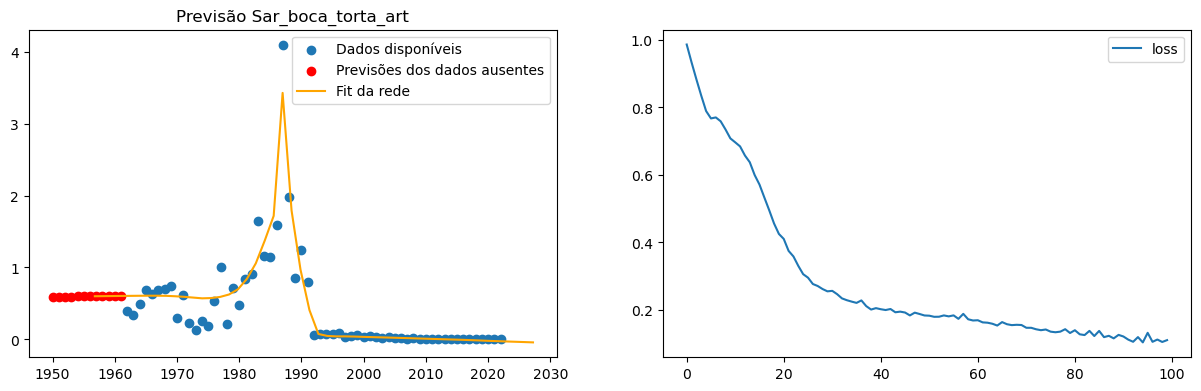

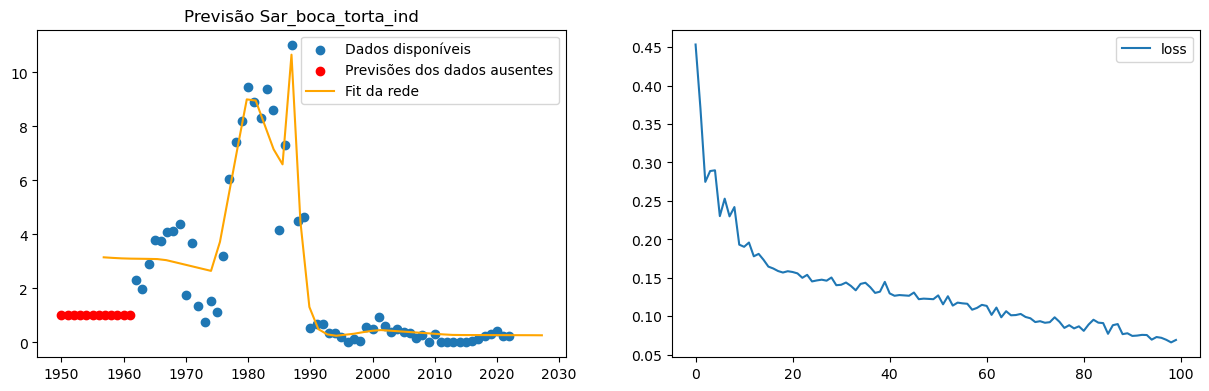

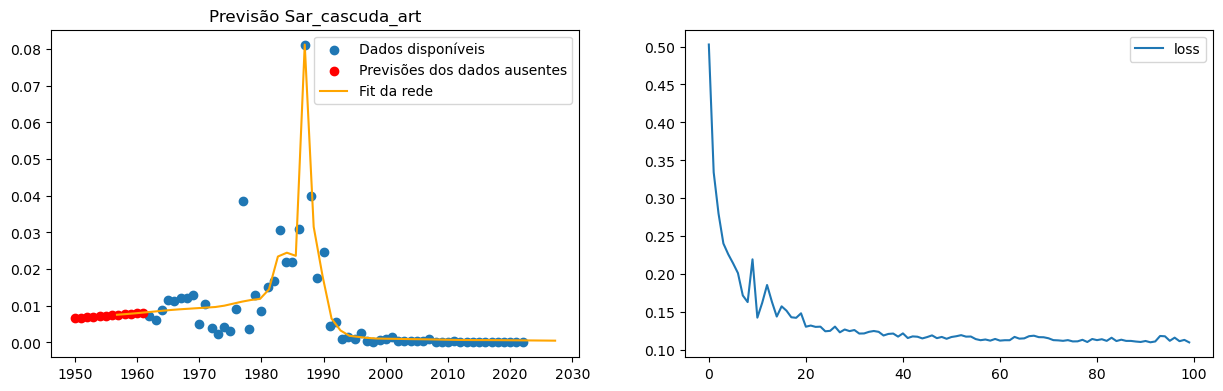

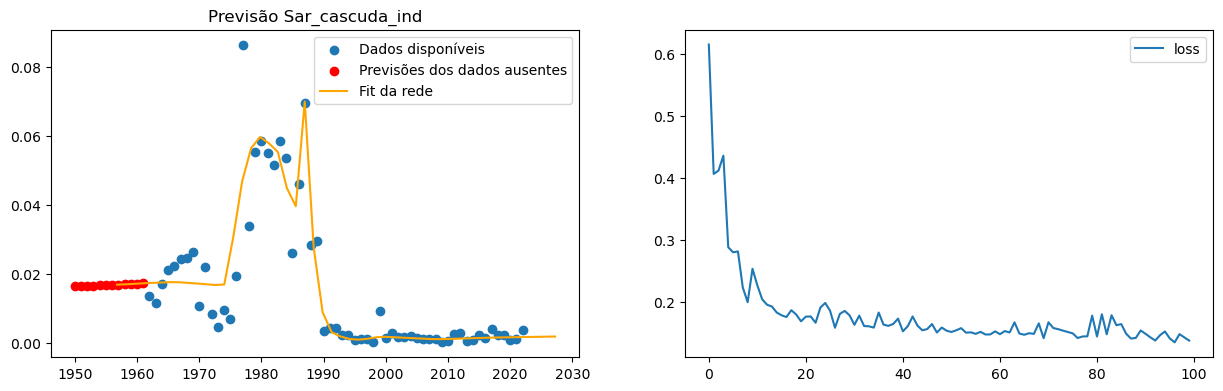

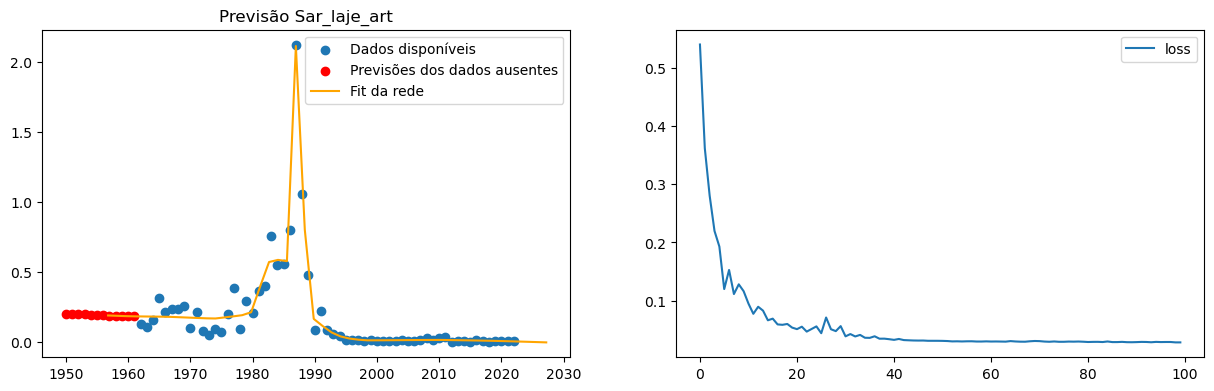

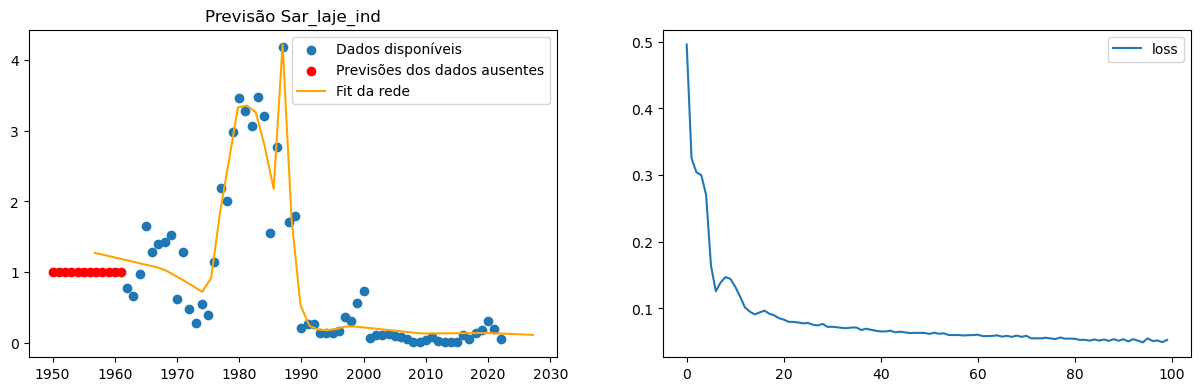

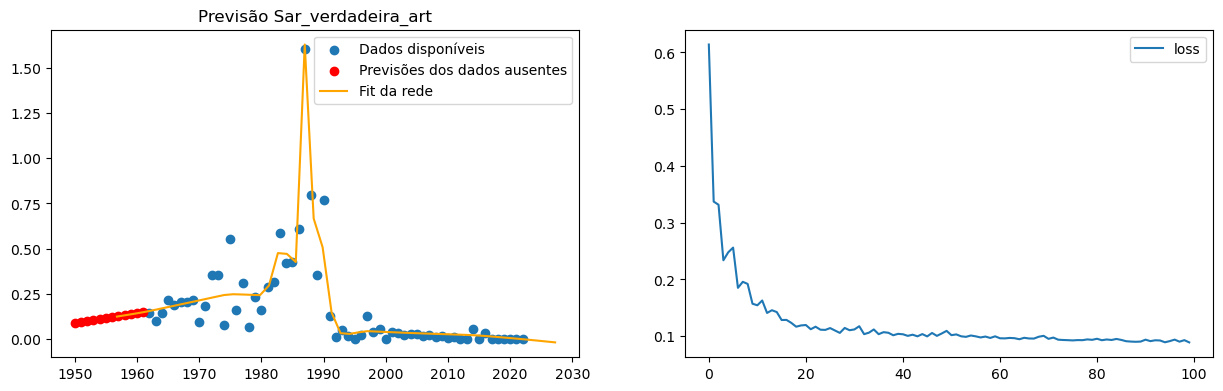

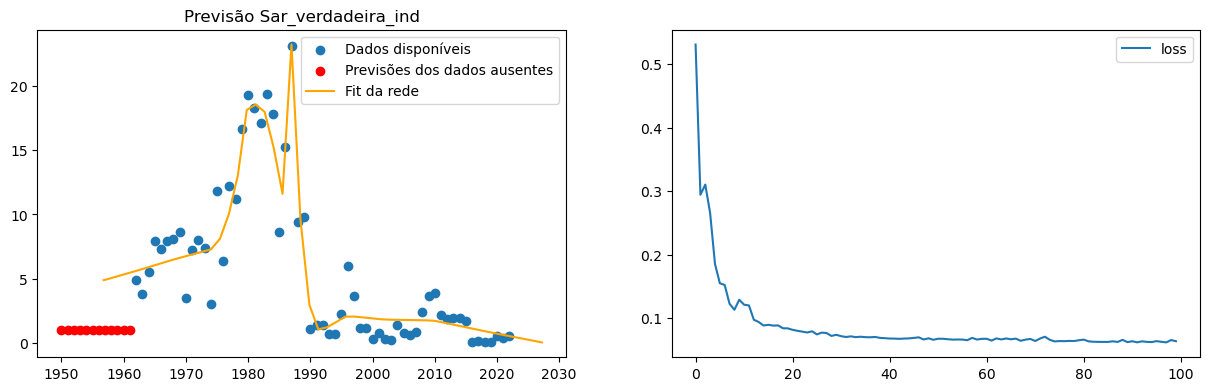

In [203]:
#Plot das previsoes e loss para cada especie
for k in range(len(especies)):
    plt.figure(figsize=(15,5*len(especies)))
    plt.subplot(len(especies),2,2*k+1 ).scatter(anos_com_dados,lista_de_prop[k],label='Dados disponíveis')
    plt.subplot(len(especies),2,2*k+1 ).scatter(anos_para_prever,lista_de_previsoes[k], color='red', label='Previsões dos dados ausentes')
    plt.subplot(len(especies),2,2*k+1 ).plot(p*ano_std + ano_mean,lista_fits[k],color='orange',label='Fit da rede')
    plt.title(f'Previsão {especies[k]}')
    plt.legend()

    plt.subplot(len(especies),2,2*k+2).plot(lista_de_loss[k],label='loss')
    plt.legend()

plt.show()

In [204]:
#Lista de anos sem buracos normalizada e sua predição      (para poder me referir por indices)
anos = np.arange(1950,np.max(anos_para_prever)+1)
anos_norm = (anos-ano_mean)/ano_std

#Previsoes sem buracos para cada especie
lista_prev_continua=[]
for k in range(len(especies)):
    model.load_weights(f'/Users/PC/Documents/Proj_MPA/Recontrucao/RJ/Clupeiformes/Extrapolações/pesos prop {especies[k]}/.weights.h5')
    prev_continua = model.predict(anos_norm)*lista_prop_std[k] + lista_prop_mean[k]
    
    for i in range(len(prev_continua)):
        if prev_continua[i]<0:
            prev_continua[i]=0
        if prev_continua[i]>=1:
            prev_continua[i]=1
    
    lista_prev_continua.append(prev_continua.flatten())
  


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [205]:
#Dicionario dos indices das espécie para prever e da que será desagregada
especies_com_desagregada = np.append(especies,'TOTAL_FISHES_M') 
todas_colunas=df.columns.to_numpy()
dic_especies={}
for k in range(len(especies_com_desagregada)):
    for i in range(len(todas_colunas)):
        if especies_com_desagregada[k]==todas_colunas[i]:
            dic_especies[especies_com_desagregada[k]]=i+1 #Índices do openpyxl
            break
print(dic_especies)

{'Sar_boca_torta_art': 2, 'Sar_boca_torta_ind': 3, 'Sar_cascuda_art': 4, 'Sar_cascuda_ind': 5, 'Sar_laje_art': 6, 'Sar_laje_ind': 7, 'Sar_verdadeira_art': 8, 'Sar_verdadeira_ind': 9, 'TOTAL_FISHES_M': 12}


In [206]:
#Adicionando novos dados na planilha e colorindo
wb = xl.load_workbook('/Users/PC/Documents/Proj_MPA/Recontrucao/RJ/Clupeiformes/R.xlsx')
ws=wb.active

for k in range(len(especies)):
    for i in range(len(anos)):
        celula=ws.cell(anos[i]-1950+2 , dic_especies[especies[k]])
        
        #Dados desagregados para células com valores mantém a cor
        if i+1950 in anos_para_prever and pd.isnull(celula.value)==False:   
          celula.value += ws.cell(anos[i]-1950+2, dic_especies['TOTAL_FISHES_M']).value*lista_prev_continua[k][i]
          celula.font = Font(color=celula.font.color,name='Calibri')


        #Dados desagregados para celulas vazias são colocados em vermelho
        if i+1950 in anos_para_prever and pd.isnull(celula.value)==True:
          celula.value = ws.cell(anos[i]-1950+2, dic_especies['TOTAL_FISHES_M']).value*lista_prev_continua[k][i]
          celula.font = Font(color='FFFF0000',name='Calibri')
          

      

wb.save('Extrapolações com proporção.xlsx')

In [207]:
   ###Caso o openpyxl não coloque todos os valores###



df_prev = df[['Ano',"Sar_boca_torta_art", "Sar_boca_torta_ind", "Sar_cascuda_art", "Sar_cascuda_ind", "Sar_laje_art", "Sar_laje_ind", "Sar_verdadeira_art", "Sar_verdadeira_ind"]]
for k in range(len(especies)):
    for i in range(len(anos)):
        if anos[i] in lista_de_anos_para_prever[k]:
            df_prev.loc[anos[i]-1950,especies[k]] = df_especies.loc[anos[i]-1950,'TOTAL_FISHES_M']*lista_prev_continua[k][i]
df_prev.to_excel('Extrapol pandas.xlsx')


PermissionError: [Errno 13] Permission denied: 'Extrapol pandas.xlsx'